In [15]:
# House Price Prediction using Machine Learning
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("boston.csv")
df.info()
df.describe()

In [17]:
df.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

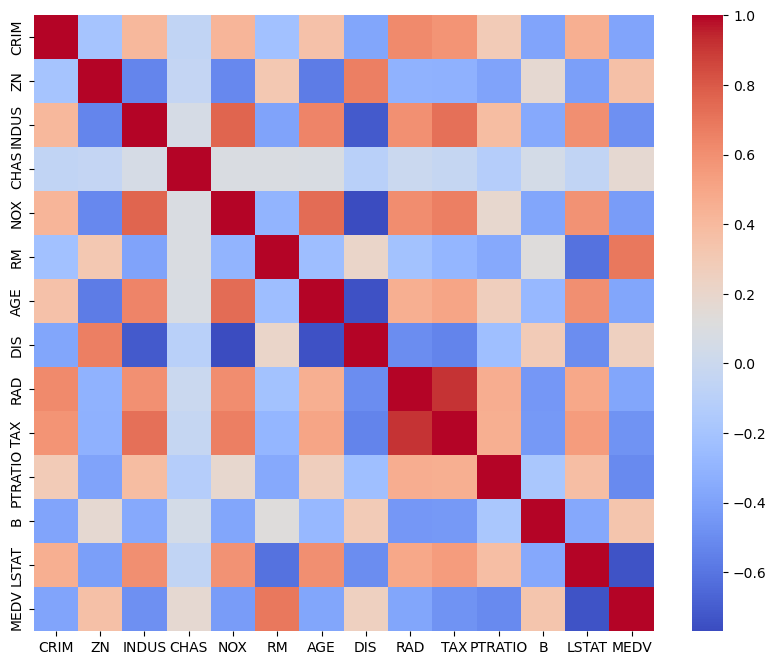

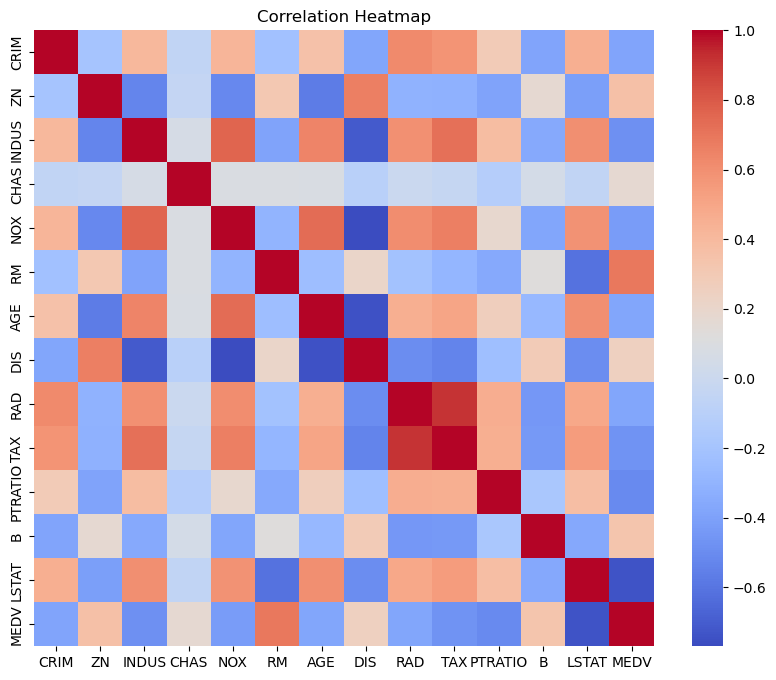

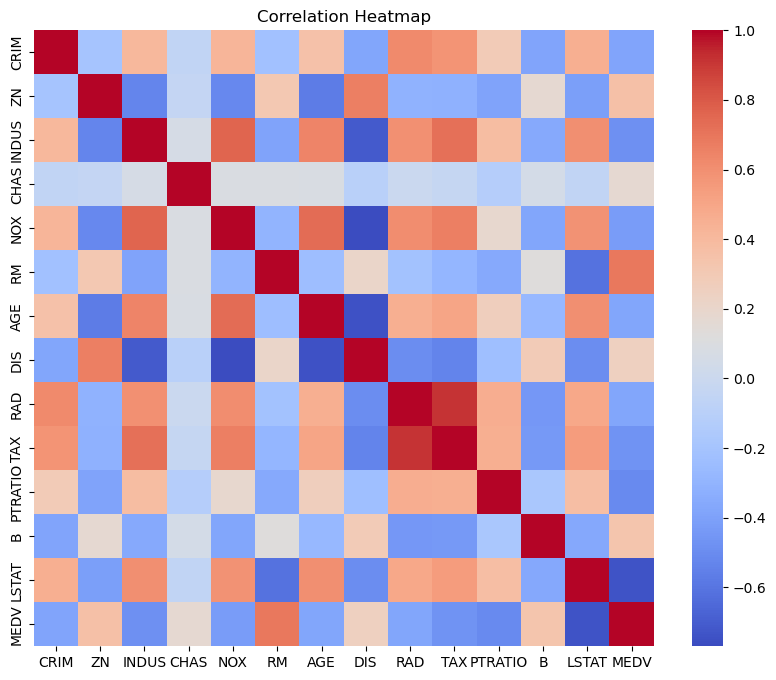

In [19]:
%matplotlib inline
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

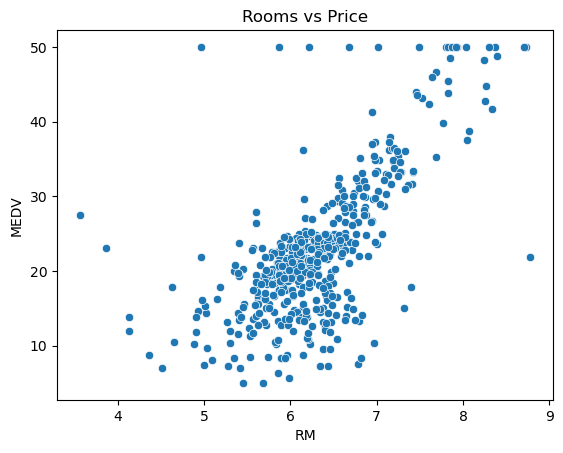

In [20]:
sns.scatterplot(x=df['RM'], y=df['MEDV'])
plt.title("Rooms vs Price")
plt.show()

In [21]:
X = df.drop("MEDV", axis=1)
y = df["MEDV"]

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [23]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [24]:
y_pred = model.predict(X_test)

In [25]:
from sklearn.metrics import r2_score, mean_absolute_error

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2 Score: 0.8922527442109116
MAE: 2.0395392156862746


In [28]:
print(f"Final R2 Score: {r2_score(y_test, y_pred):.2f}")

Final R2 Score: 0.89


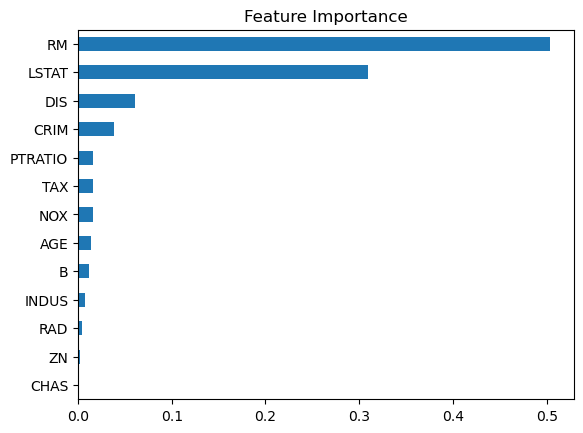

In [26]:
importance = model.feature_importances_
features = pd.Series(importance, index=X.columns)

features.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

In [27]:
import pickle

pickle.dump(model, open("model.pkl", "wb"))